In [22]:
# import needed libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import json
from collections import defaultdict
import shutil
import cv2
from matplotlib import pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

In [2]:
# load the metadata from dataset.csv

metadata = pd.read_csv('FracAtlas/dataset.csv')
print("Shape of the dataset", metadata.shape)
# prints in a table format the first 10 entries of the dataset.csv dataset
metadata.head(10)

Shape of the dataset (4083, 13)


,image_id,hand,leg,hip,shoulder,mixed,hardware,multiscan,fractured,fracture_count,frontal,lateral,oblique
0,IMG0000000.jpg,0,1,0,0,0,0,1,0,0,1,1,0
1,IMG0000001.jpg,0,1,0,0,0,0,1,0,0,1,1,0
2,IMG0000002.jpg,0,1,0,0,0,0,1,0,0,1,1,0
3,IMG0000003.jpg,0,1,0,0,0,0,1,0,0,0,1,1
4,IMG0000004.jpg,0,1,0,0,0,0,1,0,0,0,1,1
5,IMG0000005.jpg,0,1,0,0,0,0,1,0,0,0,1,1
6,IMG0000006.jpg,1,0,0,0,0,0,1,0,0,0,1,1
7,IMG0000007.jpg,1,0,0,0,0,0,0,0,0,0,0,1
8,IMG0000008.jpg,0,1,0,0,0,0,1,0,0,0,1,1
9,IMG0000009.jpg,0,1,0,0,0,0,0,0,0,0,0,1


In [10]:
# check image type
img = cv2.imread("FracAtlas/images/Fractured/IMG0000019.jpg")
print(img.shape)

(2880, 2304, 3)


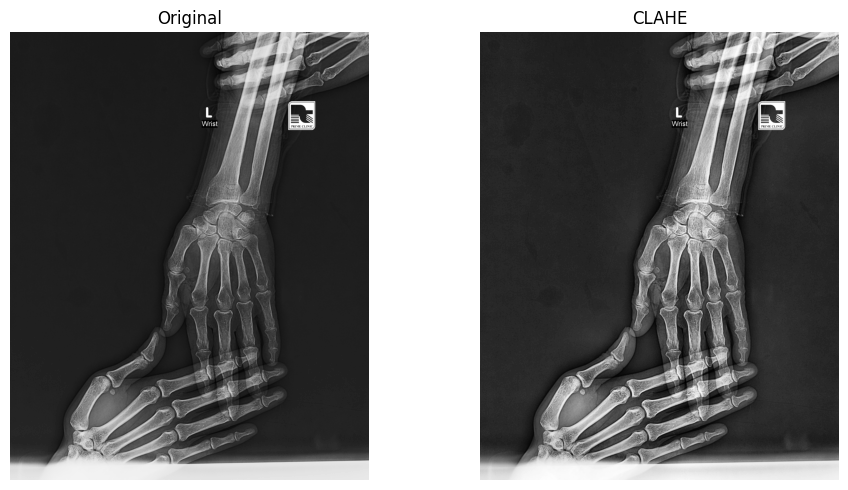

In [11]:
#clash image enhancement example

# Load the image in grayscale (or convert to grayscale first)
img = cv2.imread('FracAtlas/images/Fractured/IMG0000019.jpg', cv2.IMREAD_GRAYSCALE)

# Create CLAHE object
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

# Apply CLAHE
cl1 = clahe.apply(img)

# Show the result
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.title('Original'), plt.imshow(img, cmap='gray'), plt.axis('off')
plt.subplot(1, 2, 2), plt.title('CLAHE'), plt.imshow(cl1, cmap='gray'), plt.axis('off')
plt.tight_layout()
plt.show()

In [13]:
# defining function to apply clash to all images in folders

def apply_clahe_to_folder(input_folder, output_folder, clip_limit=2.0, tile_grid_size=(8, 8)):
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)

    # Loop through each file in the input folder
    for filename in os.listdir(input_folder):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
            input_path = os.path.join(input_folder, filename)
            output_path = os.path.join(output_folder, filename)

            # Read the image
            img = cv2.imread(input_path)

            # Convert to LAB color space
            lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
            l, a, b = cv2.split(lab)

            # Apply CLAHE to the L channel
            clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
            cl = clahe.apply(l)

            # Merge and convert back to BGR
            enhanced_lab = cv2.merge((cl, a, b))
            enhanced_img = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)

            # Save the result
            cv2.imwrite(output_path, enhanced_img)

In [16]:
# apply clahe
apply_clahe_to_folder("FracAtlas/images/Fractured", "FracAtlas/images/CLAHE/Fractured")
apply_clahe_to_folder("FracAtlas/images/Non_fractured", "FracAtlas/images/CLAHE/Non_fractured")

Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
P

In [17]:
# sorting through the fractured and non-fractured images and sorting into fracture location folders

source_dir_fractured = "FracAtlas/images/CLAHE/Fractured"
source_dir_non_fractured = "FracAtlas/images/CLAHE/Non_fractured"
target_base_dir_fractured = 'FracAtlas/images/sorted_images/Fractured'
target_base_dir_non_fractured = 'FracAtlas/images/sorted_images/Non_fractured'

# Relevant body parts
categories = ['hand', 'leg', 'hip', 'shoulder', 'mixed']

# Create subfolders if they don't exist
for category in categories:
    os.makedirs(os.path.join(target_base_dir_fractured, category), exist_ok=True)

# Create subfolders if they don't exist
for category in categories:
    os.makedirs(os.path.join(target_base_dir_non_fractured, category), exist_ok=True)

# Loop through rows and move files in the Fractured folder
for _, row in metadata.iterrows():
    image_filename = row['image_id']
    if row['fractured'] == 1:
        for category in categories:
            if row[category] == 1:
                source_path = os.path.join(source_dir_fractured, image_filename)
                target_path = os.path.join(target_base_dir_fractured, category, image_filename)
                if os.path.exists(source_path):  # Ensure the image exists
                    shutil.copy(source_path, target_path)  
                else:
                    print(f"File not found: {source_path}")

# Loop through rows and move files in the Non_fractured folder
for _, row in metadata.iterrows():
    image_filename = row['image_id']
    if row['fractured'] == 0:
        for category in categories:
            if row[category] == 1:
                source_path = os.path.join(source_dir_non_fractured, image_filename)
                target_path = os.path.join(target_base_dir_non_fractured, category, image_filename)
                if os.path.exists(source_path):  # Ensure the image exists
                    shutil.copy(source_path, target_path) 
                else:
                    print(f"File not found: {source_path}")


In [18]:
# combining the folders from above to one set of fracture location folders

# Base directories
fractured_dir = "FracAtlas/images/sorted_images/Fractured"
non_fractured_dir = "FracAtlas/images/sorted_images/Non_fractured"
combined_dir = "FracAtlas/images/sorted_images/Combined"

# Categories to merge
categories = ['hand', 'leg', 'hip', 'shoulder', 'mixed']

# Make combined folders
for category in categories:
    os.makedirs(os.path.join(combined_dir, category), exist_ok=True)

    # Source directories (fractured and non-fractured)
    src_dirs = [
        os.path.join(fractured_dir, category),
        os.path.join(non_fractured_dir, category)
    ]

    # Copy files from both
    for src in src_dirs:
        for filename in os.listdir(src):
            src_path = os.path.join(src, filename)
            dest_path = os.path.join(combined_dir, category, filename)

            # Avoid overwriting same filename
            if os.path.exists(dest_path):
                name, ext = os.path.splitext(filename)
                dest_path = os.path.join(combined_dir, category, f"{name}_copy{ext}")

            shutil.copy(src_path, dest_path)

In [21]:
# median frequency balancing between all images (fractured and non-fractured)

label = [ 'hand', 'leg','hip','shoulder','mixed']

def estimate_weights_mfb(label):
    class_weights = np.zeros_like(label, dtype=float)
    counts = np.zeros_like(label)
    for i,l in enumerate(label):
        counts[i] = metadata[metadata[l] == 1].shape[0]
    counts = counts.astype(float)
    median_freq = np.median(counts)
    for i, label in enumerate(label):
        class_weights[i] = median_freq / counts[i]
    return class_weights

classweight= estimate_weights_mfb(label)

for i in range(len(label)):
    print(label[i],":", classweight[i])

hand : 0.258777633289987
leg : 0.17509898812142544
hip : 1.1775147928994083
shoulder : 1.140401146131805
mixed : 1.0


In [24]:
# data augmentation

# normalization values for pretrained resnet on Imagenet
norm_mean = (0.485, 0.456, 0.406)
norm_std = (0.229, 0.224, 0.225)

batch_size = 128
validation_batch_size = 10
test_batch_size = 10

# We compute the weights of individual classes and convert them to tensors
class_weights = estimate_weights_mfb(label)
class_weights = torch.FloatTensor(class_weights)

def transform_images(image_size=(224,224)):
    transform_train = transforms.Compose([
                        transforms.Resize(image_size),
                        transforms.RandomHorizontalFlip(),
                        transforms.RandomRotation(degrees=60),
                        transforms.ToTensor(),
                        transforms.Normalize(norm_mean, norm_std),
                        ])
    
    transform_test = transforms.Compose([
                        transforms.Resize(image_size),
                        transforms.ToTensor(),
                        transforms.Normalize(norm_mean, norm_std),
                        ])
    
    return transform_train, transform_test



Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.201))
)
